## STOCHASTIC MODELING
MODULE 5 | LESSON 2


---


# **MARKOV CHAINS: AN APPLICATION**

|  |  |
|:---|:---|
|**Reading Time** |  50 minutes |
|**Prior Knowledge** |Markov models, Monte Carlo  |
|**Keywords** |Markov Process, Markov chains, Transition Matrix, Bond valuation


---

As we become familiar with Markov models, it is convenient to see them in practice. In this lesson, we will use Markov chains to model firm risk, as proxied by its credit rating. Then, we will see how we can use this information for bond valuation.

In [2]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1121456979", h="3298dbabb7", width=700, height=450)

## **1. Markov chains and Credit Ratings**

Credit ratings provide investors with valuable information to assess firms' abilities to meet their debt obligations, i.e., the probability of default.

\
Ratings are published periodically and change from time to time to reflect firms' changes in credit risk. Thus, we can use a Markov chain model to identify the dynamics of a firm's credit rating.

\
To define the problem formally, consider a homogeneous Markov chain $S_t$ defined on the state space $\mathcal{S}=\{1,2,...,D-1,D\}$ with transition matrix $P$. State 1 represents the highest credit class, state 2 the second highest, and so on, while state $D-1$ refers to the lowest credit class, and state $D$ represents default (an absorbing state).

\
The table below shows the actual transition probabilities for credit ratings published by Standard & Poor's (NR stands for *'rating withdrawn'*). Obviously, this is the key ingredient for our model, but also the type of information that is harder to get in practice. For now, let's leverage the data from S&P:

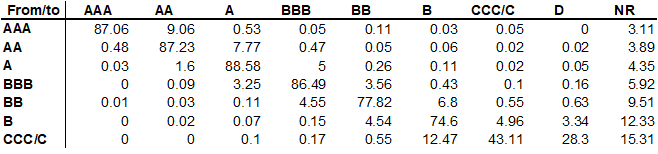

Let's start by importing libraries needed and setting up some printout options:

In [1]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import rand, seed
from scipy.stats import norm

# Printout options and fixing random seed
seed(12345)
np.set_printoptions(precision=3, suppress=True)

Then, let's hardcode the previous transition matrix. In the process, we will get rid of the "NR" type, as its not really clear what rating withdrawn can mean in this context. Also, this requires us to further normalize the transition probabilities so that they sum up to one again (i.e., after removing NR):

In [2]:
P0 = np.array(
    [
        [87.06, 9.06, 0.53, 0.05, 0.11, 0.03, 0.05, 0.0, 3.11],
        [0.48, 87.23, 7.77, 0.47, 0.05, 0.06, 0.02, 0.02, 3.89],
        [0.03, 1.6, 88.58, 5.0, 0.26, 0.11, 0.02, 0.05, 4.35],
        [0, 0.09, 3.25, 86.49, 3.56, 0.43, 0.1, 0.16, 5.92],
        [0.01, 0.03, 0.11, 4.55, 77.82, 6.8, 0.55, 0.63, 9.51],
        [0.0, 0.02, 0.07, 0.15, 4.54, 74.6, 4.96, 3.34, 12.33],
        [0.0, 0.0, 0.1, 0.17, 0.55, 12.47, 43.11, 28.3, 15.31],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 100.0, 0.0],
    ])

# Ignore the NR type
P = P0[:, 0 : P0.shape[1] - 1]

# Normalize the transition probabilities
P = (P.T / np.sum(P, axis=1)).T

print(P)

[[0.899 0.094 0.005 0.001 0.001 0.    0.001 0.   ]
 [0.005 0.908 0.081 0.005 0.001 0.001 0.    0.   ]
 [0.    0.017 0.926 0.052 0.003 0.001 0.    0.001]
 [0.    0.001 0.035 0.919 0.038 0.005 0.001 0.002]
 [0.    0.    0.001 0.05  0.86  0.075 0.006 0.007]
 [0.    0.    0.001 0.002 0.052 0.851 0.057 0.038]
 [0.    0.    0.001 0.002 0.006 0.147 0.509 0.334]
 [0.    0.    0.    0.    0.    0.    0.    1.   ]]


Then, it's time to check the convergence properties of the transition matrix. The current matrix $P$ gives us the short-term (e.g., 1-year) transition probabilities, but what about the long-term behavior of these probabilities?

\
As we saw in the previous lesson, we can check this by simply using powers of the transition matrix. This is important to assess for a series of reaons:

1. **Steady-state distribution**: informs about long-run properties of firms in each tranche of  the $P$ matrix. For instance, computing $P^{10}$ we can assess the distribution of firms in each rating within 10 years.

2. **Absorbing state**: what's the probability for each firm in the long-run to eventually enter into default state? This is something we can assess using, for instance, $P^{200}$.

3. **Long-run risk management**: if we want to price a long-term bond, we might be interested in transition probabilities in the long run, rather than on a short time span.

In [3]:
# Verify where the ratings process converges given these estimates

P10 = np.linalg.matrix_power(P, 10)
print('P^{10}', P10)

P50 = np.linalg.matrix_power(P, 50)
print('P^{50}', P50)

P200 = np.linalg.matrix_power(P, 200)
print('P^{200}', P200)

P^{10} [[0.353 0.387 0.192 0.046 0.011 0.006 0.001 0.005]
 [0.021 0.42  0.395 0.124 0.021 0.01  0.002 0.008]
 [0.003 0.083 0.541 0.276 0.055 0.023 0.003 0.016]
 [0.001 0.019 0.182 0.515 0.156 0.07  0.01  0.047]
 [0.    0.005 0.044 0.203 0.311 0.228 0.031 0.178]
 [0.    0.002 0.012 0.054 0.154 0.302 0.045 0.432]
 [0.    0.001 0.005 0.018 0.052 0.115 0.018 0.79 ]
 [0.    0.    0.    0.    0.    0.    0.    1.   ]]
P^{50} [[0.013 0.104 0.293 0.262 0.096 0.062 0.009 0.161]
 [0.006 0.075 0.26  0.263 0.103 0.071 0.01  0.211]
 [0.004 0.056 0.221 0.247 0.105 0.075 0.011 0.282]
 [0.003 0.038 0.163 0.204 0.096 0.073 0.01  0.412]
 [0.001 0.019 0.088 0.122 0.065 0.054 0.008 0.642]
 [0.001 0.009 0.041 0.06  0.035 0.031 0.004 0.819]
 [0.    0.003 0.015 0.022 0.013 0.011 0.002 0.934]
 [0.    0.    0.    0.    0.    0.    0.    1.   ]]
P^{200} [[0.001 0.011 0.044 0.053 0.024 0.018 0.003 0.847]
 [0.001 0.01  0.04  0.047 0.022 0.016 0.002 0.862]
 [0.001 0.009 0.035 0.042 0.019 0.014 0.002 0.878]
 [0.   

With this information, we can actually simulate, based on the 1-year transition probabilities, how long can it take for a firm to default, which has important implications down the road:

In [4]:
# Model ratings from string to numeric using a dictionary

RATINGS = dict(
    [("AAA", 0),
        ("AA", 1),
        ("A", 2),
        ("BBB", 3),
        ("BB", 4),
        ("B", 5),
        ("CCC", 6),
        ("D", 7),])

Suppose a firm has a current rating 'CCC', how long does it take for it to default?

In [5]:
CURR_RATING = "CCC"   # Set current rating

N_HISTORIES = 1000   # Number of simulations in our MonteCarlo simulation
LEN_HIST = 100        # We are assessing this over a maximum of 100 years

histories = np.zeros((N_HISTORIES, LEN_HIST), np.int8)  # Initialize the matrix computing rating transitions to zeroes
histories[:, 0] = RATINGS[CURR_RATING]   # Departing from current rating
randarray = rand(N_HISTORIES, LEN_HIST)   # Random sampling array
default_time = np.zeros(N_HISTORIES)      # Initialize default time vector
default_sum = 0                         # We depart from 0 defaults by the firm

We can simulate for N_histories over 100 years the potential defaults the firm would incurr in. Then, we can average over N_histories to obtain an estimate of expected time-to-default:


In [6]:
# Simulate firm next-years credit rating based on P matrix:
for i in range(0, N_HISTORIES):
    for j in range(1, LEN_HIST):
        for r in RATINGS:
            if randarray[i, j] < np.cumsum(P[histories[i, j - 1], :])[RATINGS[r]]:
                histories[i, j] = RATINGS[r]
                break
        if histories[i, j] == RATINGS["D"]:   # simulation stops once the firms enters default
            break
    # Compute the average time to default
    if np.max(histories[i, :]) == RATINGS["D"]:
        where_default = np.where((histories[i, :] == RATINGS["D"]))
        default_time[i] = where_default[0][0]
        default_sum += 1
    else:
        default_time[i] = 0.0

In [7]:
print("Default time:", np.sum(default_time) / default_sum)

Default time: 8.28688524590164


So, under these transition probabilities and the simulation we have performed, on average a firm starting with a rating of "CCC" today would default in a bit more than 8 years


## **2. Bond Valuation with ratings' transition matrices**

As you can guess, the kind of estimations we performed in the previous section can be very useful when we are pricing assets that intrinsically depend on the firms' survival, for example corporate bonds. Let's see next an example of how to use Markov chains and transition matrices to price corporate bonds.

\
Consider a corporation that has an outstanding bond that has been rated as BB and matures in 5 years, with a 4% annual coupon. The current forward interest rates for years 1 to 4 appear in the table below (in percentages).

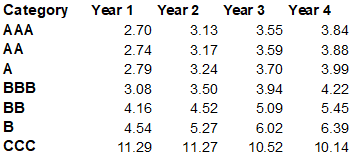

The matrix above gives us an estimation of the term structure of interest rates for each rating class. For instance, the 2.7% for AAA in year 1, means that the expected interest rate from year 1 to year 2 is 2.7% for AAA bonds.Thus, we can compute the bond value, in one year, for each possible future state. Notice that we do not need the current spot rate (i.e., the interest rate from year 0 to year 1) because we are doing a one-year forward valuation (that is, we will get the value of the bond at the end of the first year).

\
With this information and the transition matrix on credit ratings we have seen in the previous section, we can compute an estimate of the 1-year-ahead value of the bond. In order to do that we need to:


* **Step 1**. Compute the present value of the bond + coupon in one year's time using the forward rates.

* **Step 2**. Compute the expected value of the bond and the distribution of value changes using the transition matrix.

\
Let's start by considering the information regarding the bond we want to price, such as the current rating, face value, and annual coupon. Additionally, we need to make an estimate of how much of the value of the bond would be recoverable if the firm defaults. In this case, let's assume this **recovery rate** is 62%:

In [8]:
CURR_RATING = "BB"
FACE = 100.0
COUPON = 4.0
D_RECOVERY = 62
MAT = 5

Then, we are going to code the information on forward rates:

In [9]:
F = np.array(
    [
        [2.70, 3.13, 3.55, 3.84],
        [2.74, 3.17, 3.59, 3.88],
        [2.79, 3.24, 3.70, 3.99],
        [3.08, 3.50, 3.94, 4.22],
        [4.16, 4.52, 5.09, 5.45],
        [4.54, 5.27, 6.02, 6.39],
        [11.29, 11.27, 10.52, 10.14],
    ]
)
print("Forward rates matrix\n", F)

N_RATINGS = P0.shape[0]
print("Number of possible Ratings =", N_RATINGS)
N_YEARS = F.shape[1]
print("Number of years in the forward rates matrix =", N_YEARS)

Forward rates matrix
 [[ 2.7   3.13  3.55  3.84]
 [ 2.74  3.17  3.59  3.88]
 [ 2.79  3.24  3.7   3.99]
 [ 3.08  3.5   3.94  4.22]
 [ 4.16  4.52  5.09  5.45]
 [ 4.54  5.27  6.02  6.39]
 [11.29 11.27 10.52 10.14]]
Number of possible Ratings = 8
Number of years in the forward rates matrix = 4


Once we have all this information, we can price the bond under usual methods. For the non-default ratings, this would be:

\
$$
V_i = C + \sum_{t=1}^{4} \frac{C}{(1 + \frac{F_{i,t}}{100})^t} + \frac{FACE}{(1 + \frac{F_{i,4}}{100})^4}
$$

\
For the default state ("D" rating), this would be easier as it is simply the face value of the bond times the recovery rate:

\
$$
V_D = FACE \times Recovery \ rate
$$

\
Let's put all this into code:

In [10]:
# Initialize bond values vector for each state (rating), including default
bond_values = np.zeros(N_RATINGS)
bond_values[N_RATINGS - 1] = D_RECOVERY/100 * FACE

# Calculate bond values for each non-default state
for r in range(0, N_RATINGS - 1):
    bond_values[r] = COUPON
    for t in range(0, N_YEARS):
        bond_values[r] = bond_values[r] + (COUPON + FACE * (N_YEARS - 1 == t)) / (
            1 + (F[r, t] / 100)
        ) ** (t + 1)

# Thus, bond values for each rating are:
print("Bond values:\n ", bond_values)

# Expected value taking into account transition probabilities
pw_values = np.multiply(bond_values, P[RATINGS[CURR_RATING], :])
bond_val = np.sum(pw_values)

# Which yield a final bond value 1 year ahead of:
print("Bond value (one-year ahead): ", bond_val)

Bond values:
  [104.707 104.561 104.165 103.328  99.058  95.969  84.461  62.   ]
Bond value (one-year ahead):  98.7026456331422


## **3. Conclusion**

Well done! We now know how to use Markov models and transition probabilities to value assets such as corporate bonds based on credit ratings. However, the usual problem we encounter in practice is how to determine these transition probabilities if they are not known ex ante. This is what we will explore in the next lesson, where we introduce **Hidden Markov Models (HMM)**.

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
